In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/salesdaily.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:")
df.head()

Shape: (2106, 13)

Columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']

First rows:


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [2]:
# Basic info
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDate range:")
df['datum'] = pd.to_datetime(df['datum'])
print(f"From: {df['datum'].min()}")
print(f"To:   {df['datum'].max()}")
print(f"Total days: {(df['datum'].max() - df['datum'].min()).days}")

datum               str
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
Year              int64
Month             int64
Hour              int64
Weekday Name        str
dtype: object

Missing values:
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

Date range:
From: 2014-01-02 00:00:00
To:   2019-10-08 00:00:00
Total days: 2105


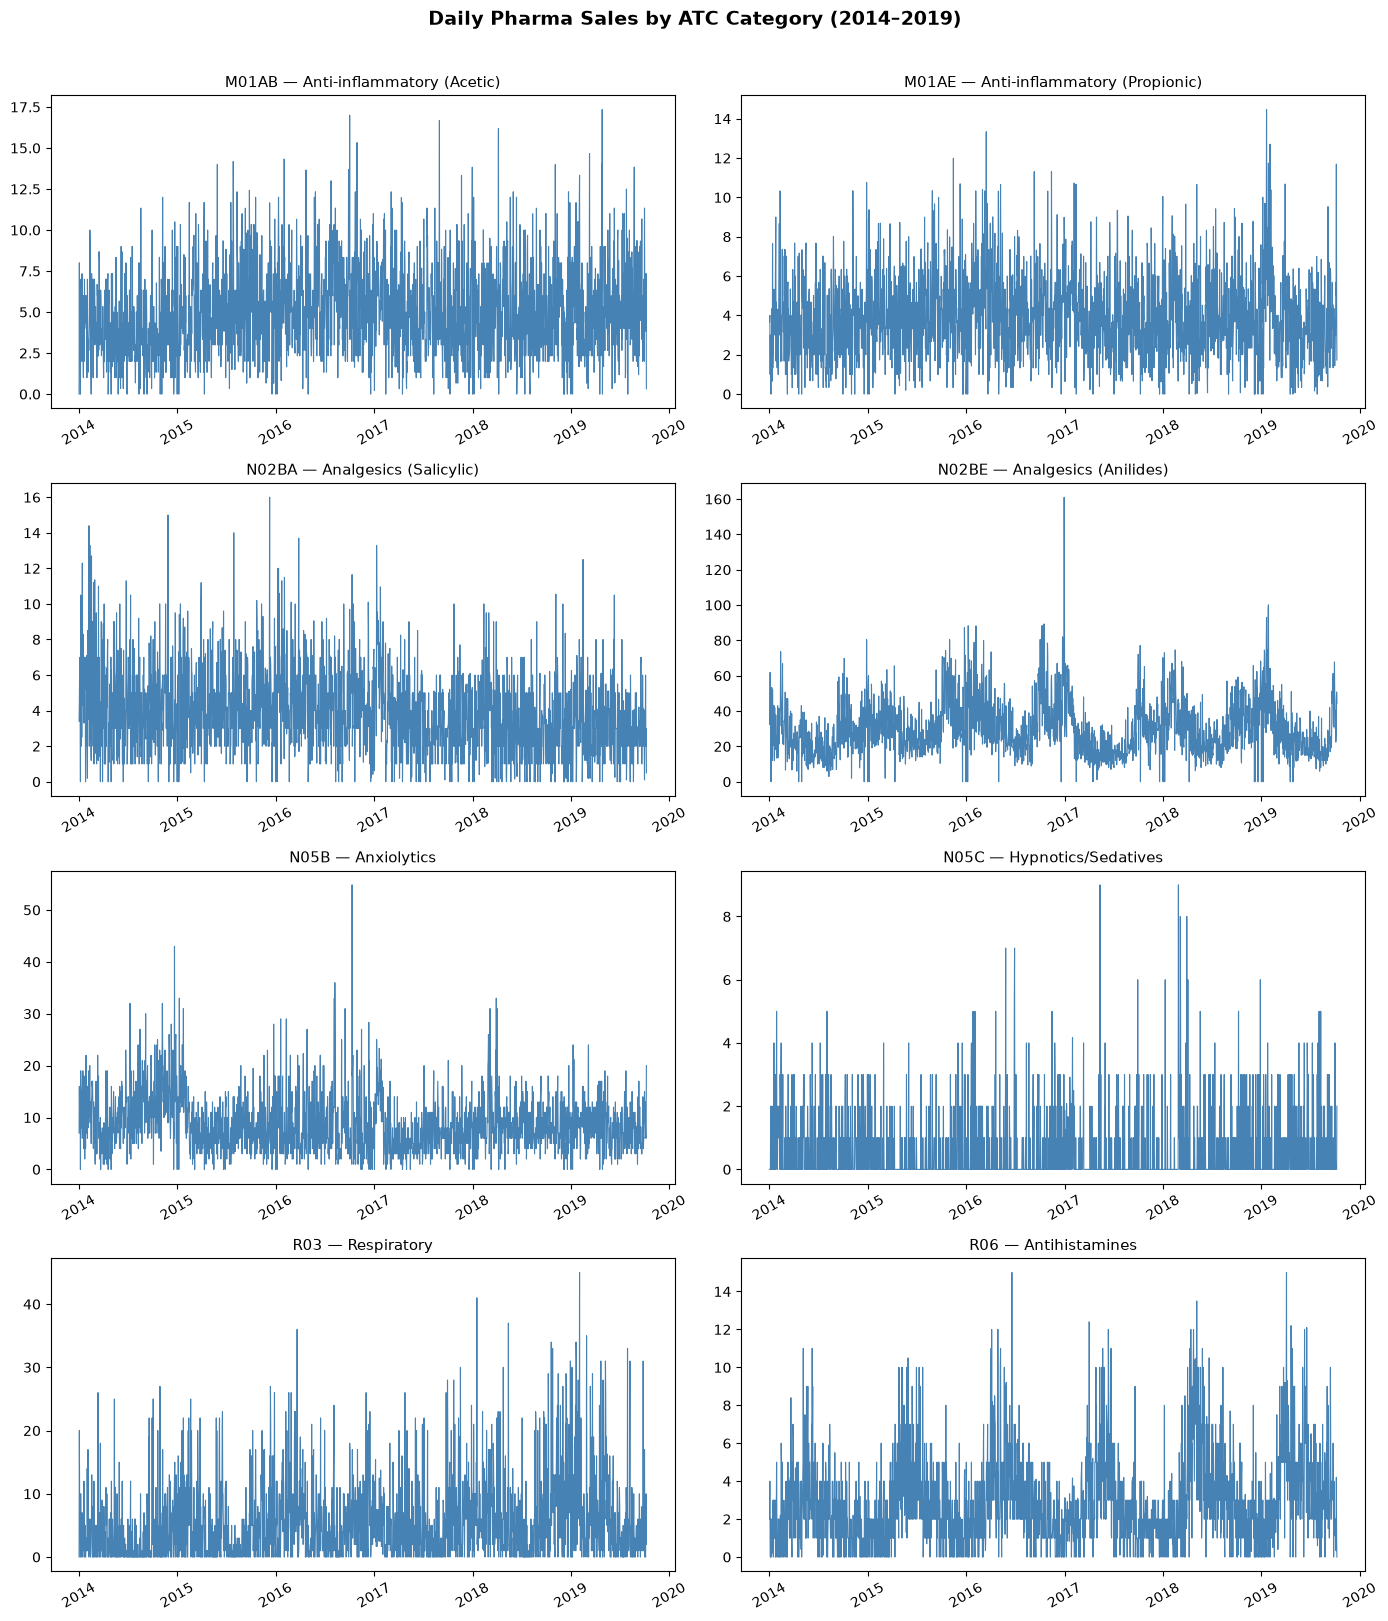

Saved!


In [3]:
atc_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

atc_labels = {
    'M01AB': 'Anti-inflammatory (Acetic)',
    'M01AE': 'Anti-inflammatory (Propionic)',
    'N02BA': 'Analgesics (Salicylic)',
    'N02BE': 'Analgesics (Anilides)',
    'N05B':  'Anxiolytics',
    'N05C':  'Hypnotics/Sedatives',
    'R03':   'Respiratory',
    'R06':   'Antihistamines'
}

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(atc_cols):
    axes[i].plot(df['datum'], df[col], linewidth=0.8, color='steelblue')
    axes[i].set_title(f"{col} — {atc_labels[col]}", fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Daily Pharma Sales by ATC Category (2014–2019)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_sales_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

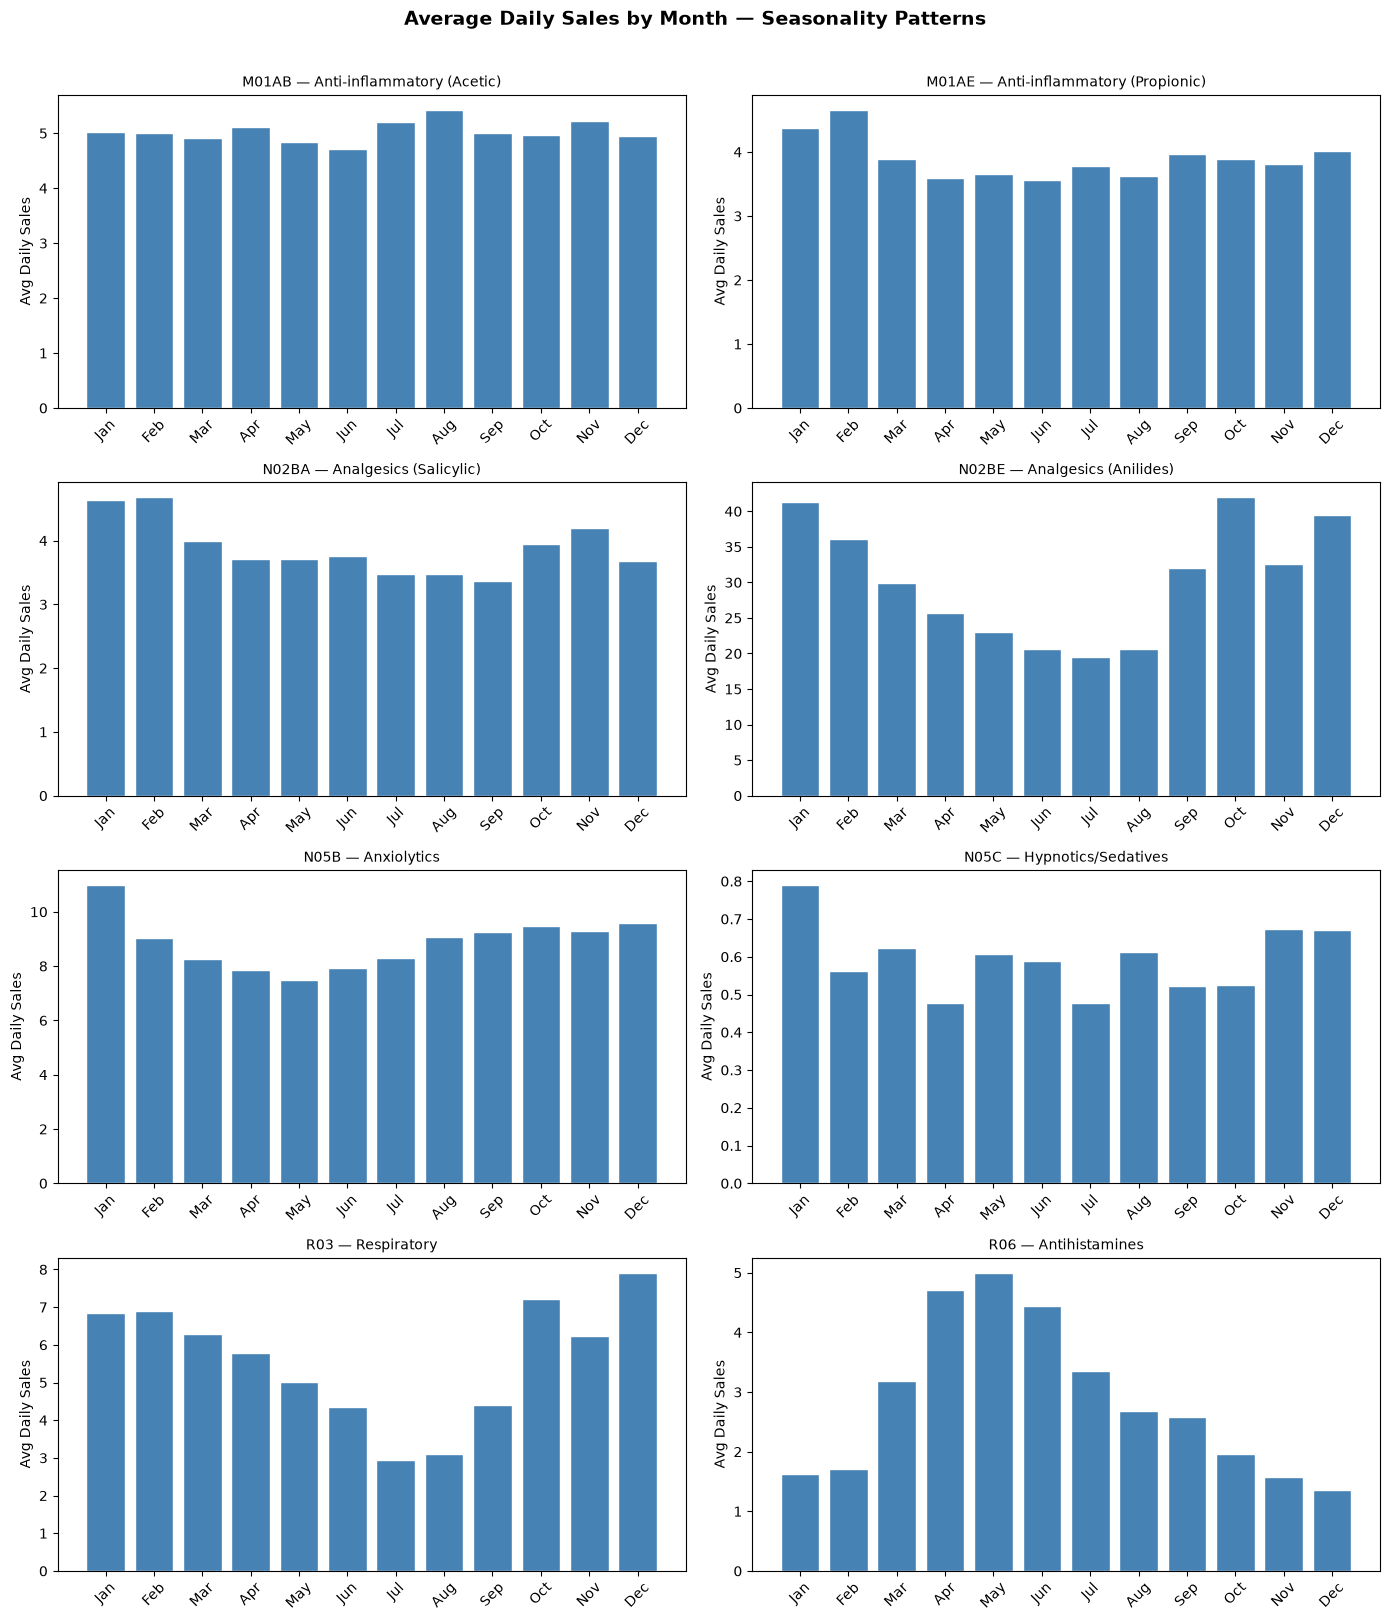

Saved!


In [4]:
df['Month'] = df['datum'].dt.month
df['Year'] = df['datum'].dt.year

# Monthly average per category
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

for i, col in enumerate(atc_cols):
    monthly_avg = df.groupby('Month')[col].mean()
    axes[i].bar(range(1,13), monthly_avg.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f"{col} — {atc_labels[col]}", fontsize=10)
    axes[i].set_xticks(range(1,13))
    axes[i].set_xticklabels(month_names, rotation=45)
    axes[i].set_ylabel('Avg Daily Sales')

plt.suptitle('Average Daily Sales by Month — Seasonality Patterns', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/02_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

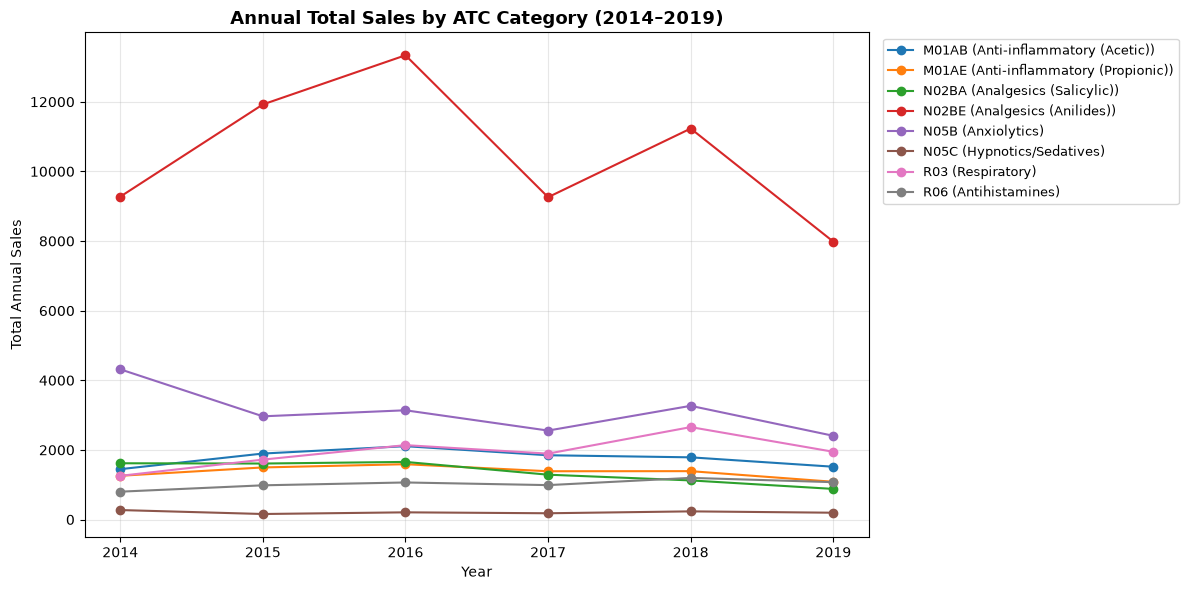

Saved!


In [5]:
# Yearly totals per category
yearly = df.groupby('Year')[atc_cols].sum()

fig, ax = plt.subplots(figsize=(12, 6))

for col in atc_cols:
    ax.plot(yearly.index, yearly[col], marker='o', label=f"{col} ({atc_labels[col]})")

ax.set_title('Annual Total Sales by ATC Category (2014–2019)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Annual Sales')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/03_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")